In [2]:
# Código para resolver o problema de tomografia quântica para o caso de 1 q-bit.
import numpy as np
from scipy.optimize import minimize, least_squares
import cvxpy as cp

In [3]:
# O objetivo dessa classe é apenas gerar o estado "desconhecido"
class QuantState:
    def __init__(self, estado):
        """
        Aceita um vetor 1D (estado puro) ou uma matriz 2D (matriz densidade / estado misto).
        """
        estado = np.array(estado, dtype=complex)
        
        if estado.ndim == 1:
            # Estado Puro: Vetor de estado |psi>
            # Normaliza o vetor por segurança
            norma = np.linalg.norm(estado)
            psi = estado / norma
            
            # Converte |psi> para a matriz densidade rho = |psi><psi|
            self.rho = np.outer(psi, psi.conj())
            
        elif estado.ndim == 2:
            # Estado Misto (ou matriz densidade já pronta)
            # Verifica se é uma matriz quadrada
            if estado.shape[0] != estado.shape[1]:
                raise ValueError("A matriz densidade deve ser quadrada.")
            
            # Normaliza o traço para garantir Tr(rho) = 1
            traco = np.trace(estado)
            self.rho = estado / traco
        else:
            raise ValueError("O estado deve ser um vetor 1D (|psi>) ou matriz 2D (rho).")
    
    def measure(self, obs):
        """
        Mede o estado em relação a um observável (matriz hermitiana).
        Retorna o valor esperado <obs> = Tr(rho * obs).
        """
        return np.trace(self.rho @ obs).real  # Retorna apenas a parte real   

In [4]:
def parametros_para_T_geral(params, n_qubits):
    """
    Generaliza a construção da matriz T de Cholesky para N qubits.
    Dimensão D = 2^N.
    """
    D = 2**n_qubits
    T = np.zeros((D, D), dtype=complex)
    
    idx = 0
    for i in range(D):
        for j in range(i + 1):
            if i == j:
                # Diagonal principal: valores reais
                T[i, j] = np.abs(params[idx]) 
                idx += 1
            else:
                # Elementos abaixo da diagonal: números complexos (real + i*imag)
                real = params[idx]
                imag = params[idx + 1]
                T[i, j] = complex(real, imag)
                idx += 2
                
    return T

def parametros_para_rho_geral(params, n_qubits):
    """Gera rho para qualquer número de qubits."""
    T = parametros_para_T_geral(params, n_qubits)
    T_dag_T = T.conj().T @ T
    traco = np.trace(T_dag_T)
    
    if np.isclose(traco, 0):
        D = 2**n_qubits
        return np.eye(D, dtype=complex) / D
        
    return T_dag_T / traco

In [5]:


def funcao_de_custo_geral(params, mediadores, dados_exp, n_qubits):
    rho_candidato = parametros_para_rho_geral(params, n_qubits)
    previsoes = [np.real(np.trace(rho_candidato @ Q)) for Q in mediadores]
    return np.sum((np.array(previsoes) - dados_exp) ** 2)

Rho Reconstruído 1:
 [[0.731+0.j  0.35 -0.2j]
 [0.35 +0.2j 0.269+0.j ]]
Rho Reconstruído 2:
 [[0.779+0.j  0.35 -0.2j]
 [0.35 +0.2j 0.221+0.j ]]
(0.7000000329940435+0j) (0.6999999718260335+0j)
(0.4000000201184695+0j) (0.40000004614623136+0j)


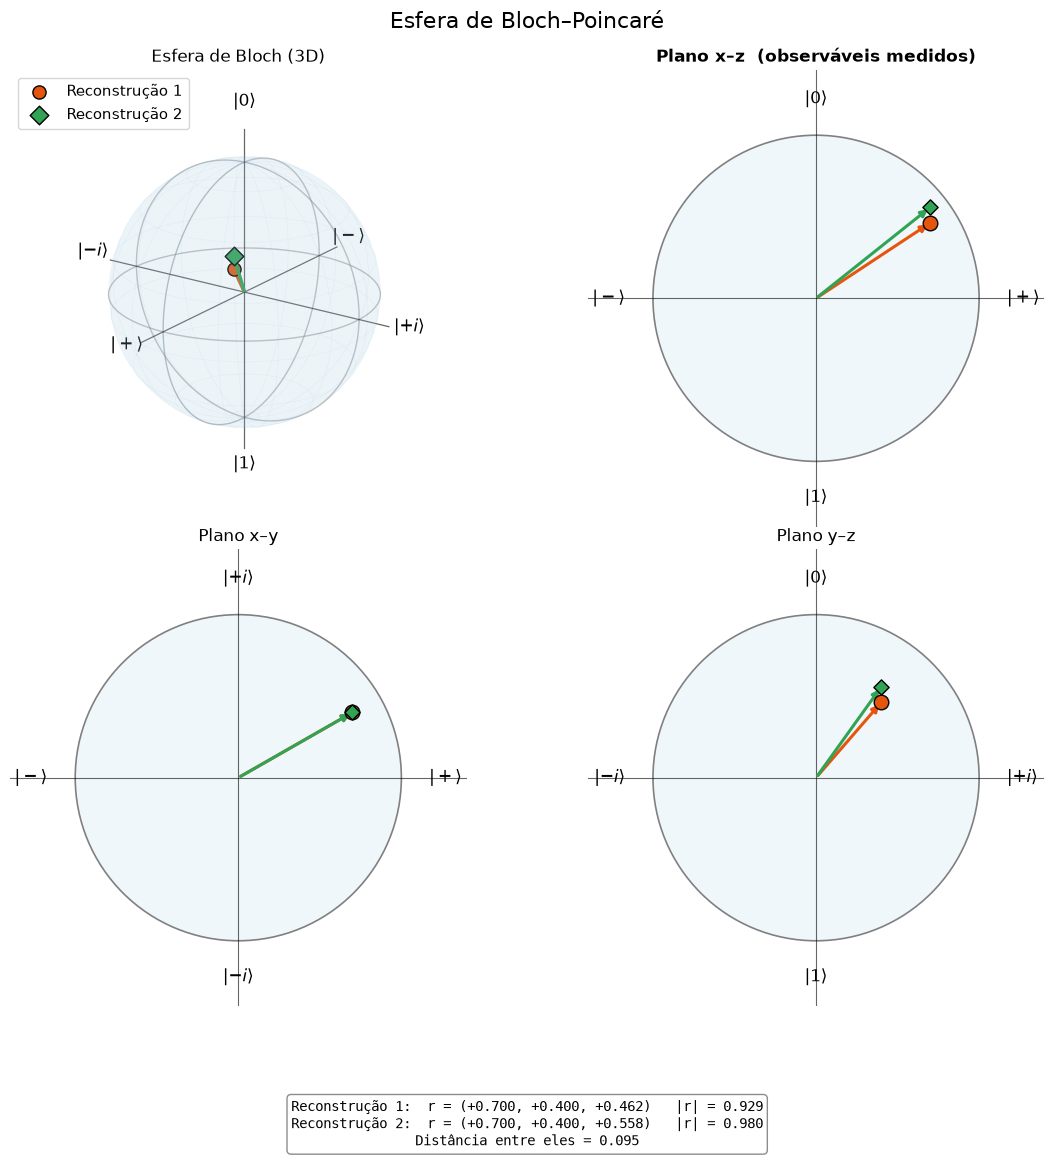

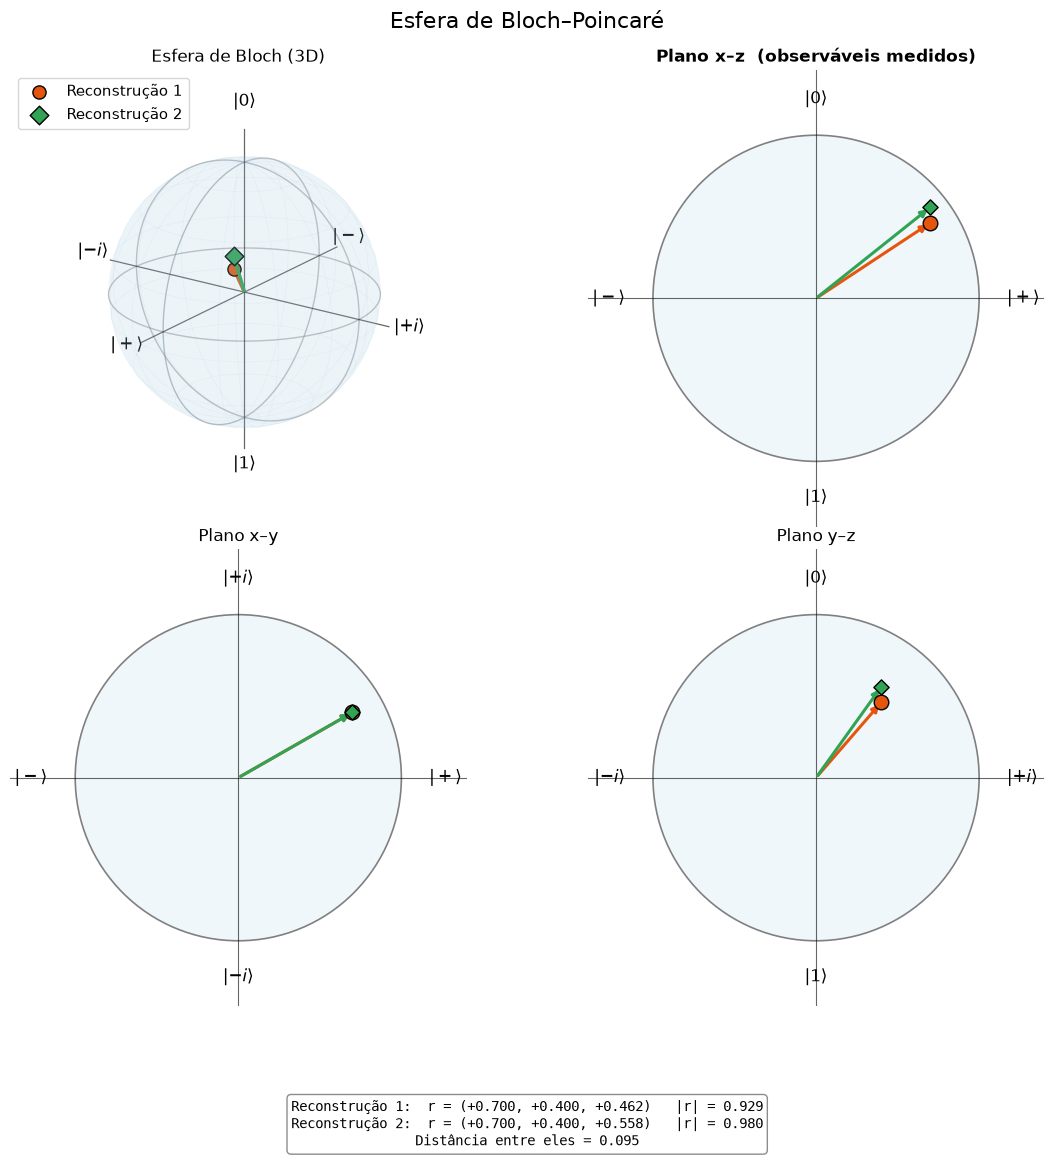

In [6]:

# Definindo as 3 Pauli para ter medição completa em 1 Qubit
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

mediadores_Q = [sigma_x,  sigma_y]


unk_state = QuantState([1, 0])
q_medidos = [0.7,0.4]
q_medidos2 = [0.7,0.4]
n_qubits = 1

# 3. Para 1 qubit -> n_qubits = 1 (precisa de 4 parametros)
num_params = (2**n_qubits)**2 # 4 parametros
chute_inicial = np.random.randn(num_params)
chute_inicial2 = np.random.randn(num_params)

# Funcao de custo para usar o modelo geral
def funcao_de_custo_geral(params, mediadores, dados_exp, n_qubits):
    rho_candidato = parametros_para_rho_geral(params, n_qubits)
    previsoes = [np.real(np.trace(rho_candidato @ Q)) for Q in mediadores]
    return (np.array(previsoes) - dados_exp)



if sum(i**2 for i in q_medidos) > 1:
    print("A soma das medidas é maior que 1, o estado reconstruído não é físico.")

"""
Vamos fazer exemplos para ilustrar possíveis situações:
1 - Se não tivermos a quantidade de medições suficiente, o estado reconstruído 
não pode ser univocamente definido, e o algoritmo pode resultar em estados diferentes.
"""

resultado1 = least_squares(
    funcao_de_custo_geral, 
    x0=chute_inicial, 
    args=(mediadores_Q, q_medidos, n_qubits), # n_qubits = 1
)

resultado2 = least_squares(
    funcao_de_custo_geral, 
    x0=chute_inicial2, 
    args=(mediadores_Q, q_medidos2, n_qubits), # n_qubits = 1
)

rho_reconstruido1 = parametros_para_rho_geral(resultado1.x, n_qubits=n_qubits)
rho_reconstruido2 = parametros_para_rho_geral(resultado2.x, n_qubits=n_qubits)

print("Rho Reconstruído 1:\n", np.round(rho_reconstruido1, 3))
print("Rho Reconstruído 2:\n", np.round(rho_reconstruido2, 3))

print(np.trace(rho_reconstruido1 @ sigma_x), np.trace(rho_reconstruido2 @ sigma_x))
print(np.trace(rho_reconstruido1 @ sigma_y), np.trace(rho_reconstruido2 @ sigma_y))

from bloch_reconstrucao import plotar_bloch   # ou cole as funções no notebook

plotar_bloch(
    [rho_reconstruido1, rho_reconstruido2],
    rotulos=["Reconstrução 1", "Reconstrução 2"],
    medidos=("x", "z"),          # destaca o plano dos observáveis que você mediu
    salvar="bloch_reconstrucoes.png",
)


In [7]:
"""Tentando fazer usando SDP"""
np.random.seed(50)
d = 2  # dimensão do ket (dimensão do sistema vai ser 2^d)
M = 3  # Número de mediadores
rho = cp.Variable((d, d), hermitian=True) #Define a variável de otimização rho como uma matriz hermitiana de dimensão d x d.


Q = [sigma_x, sigma_y, sigma_z] # Observáveis
q = np.random.rand(M) # Valores esperados das medições


#Vínculos do problema
constraints = [
    # 
    rho >> 0,
    cp.trace(rho) == 1
] 

for i in range(M):
    constraints.append(
        cp.real(cp.trace(Q[i] @ rho)) == q[i]
    )


# Função para resolver o problema de viabilidade semidefinida
problem = cp.Problem(
    cp.Minimize(0),
    constraints
)


problem.solve()
print(problem.status)
print(rho.value)


optimal
[[0.62773698+0.j         0.24730083-0.11404156j]
 [0.24730083+0.11404156j 0.37226305+0.j        ]]
